# Colab Gemma 4 Multimodal (Transformers + 4-bit)

This notebook loads a Gemma 4 multimodal checkpoint with 4-bit quantization using transformers + bitsandbytes. It supports image + text inputs when the model class is available.

In [ ]:
!pip -q install -U "transformers>=4.45.0" accelerate bitsandbytes "pillow==11.0.0" safetensors sentencepiece fastapi uvicorn pyngrok pydantic nest-asyncio


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.3/472.3 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 58.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pydantic<=2.12.3,>=2.0, but you have pydantic 2.13.4 which is incompatible.


In [ ]:
import os
try:
    from google.colab import userdata
    hf_token = userdata.get('HF_TOKEN')
except Exception:
    from kaggle_secrets import UserSecretsClient
    hf_token = UserSecretsClient().get_secret('HF_TOKEN')

os.environ['HF_TOKEN'] = hf_token
print('HF token loaded:', bool(hf_token))


HF token loaded: True


In [ ]:
import inspect
import torch
from transformers import BitsAndBytesConfig

# Pick a Gemma 4 checkpoint from https://huggingface.co/collections/google/gemma-4
# This model supports image + text + audio (E2B/E4B) and outputs text.
MODEL_ID = 'google/gemma-4-E2B-it'

# CRITICAL FIX FOR KAGGLE/T4 GPUs:
# Kaggle's T4 GPUs DO NOT support bfloat16. Using bfloat16 compute on a T4 causes
# catastrophic numeric corruption in the vision encoder, resulting in "static/gray noise".
# We must use torch.float16 for the compute dtype so it runs correctly on T4 architecture.
#
# Hybrid safety: skip quantization for vision + projector modules so the image path stays intact.
SKIP_MODULES = [
    'vision_tower',
    'vision_model',
    'vision_encoder',
    'vision_backbone',
    'vision',
    'mm_projector',
    'multi_modal_projector',
    'vision_proj',
    'vision_projection',
    'image_projector',
    'vision_adapter',
    'connector',
]

# Use fp16-only to avoid bitsandbytes runtime errors. Switch back to int8/4bit if needed.
QUANT_MODE = 'none'  # 'none', 'int8', '4bit'

quant_config = None
if QUANT_MODE == 'int8':
    bnb_kwargs = dict(load_in_8bit=True)
    if 'llm_int8_enable_fp32_cpu_offload' in inspect.signature(BitsAndBytesConfig).parameters:
        bnb_kwargs['llm_int8_enable_fp32_cpu_offload'] = True
    if 'llm_int8_skip_modules' in inspect.signature(BitsAndBytesConfig).parameters:
        bnb_kwargs['llm_int8_skip_modules'] = SKIP_MODULES
    quant_config = BitsAndBytesConfig(**bnb_kwargs)
elif QUANT_MODE == '4bit':
    bnb_kwargs = dict(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )
    if 'llm_int8_skip_modules' in inspect.signature(BitsAndBytesConfig).parameters:
        bnb_kwargs['llm_int8_skip_modules'] = SKIP_MODULES
    quant_config = BitsAndBytesConfig(**bnb_kwargs)

In [ ]:
import inspect
from transformers import AutoProcessor, AutoTokenizer, AutoModelForCausalLM

try:
    from transformers import AutoModelForImageTextToText
except Exception:
    AutoModelForImageTextToText = None

try:
    from transformers import AutoModelForVision2Seq
except Exception:
    AutoModelForVision2Seq = None

processor = AutoProcessor.from_pretrained(
    MODEL_ID, token=os.environ['HF_TOKEN'], trust_remote_code=True
)

model = None
model_class = None

def build_model_kwargs(model_cls):
    kwargs = dict(
        device_map='auto',
        torch_dtype=torch.float16,  # Force float16
        token=os.environ['HF_TOKEN'],
        trust_remote_code=True,
    )
    if quant_config is not None:
        kwargs['quantization_config'] = quant_config
        if QUANT_MODE == 'int8' and 'offload_buffers' in inspect.signature(model_cls.from_pretrained).parameters:
            kwargs['offload_buffers'] = True
    return kwargs

if AutoModelForImageTextToText is not None:
    try:
        model = AutoModelForImageTextToText.from_pretrained(
            MODEL_ID,
            **build_model_kwargs(AutoModelForImageTextToText),
        )
        model_class = 'AutoModelForImageTextToText'
    except Exception:
        model = None

if model is None and AutoModelForVision2Seq is not None:
    try:
        model = AutoModelForVision2Seq.from_pretrained(
            MODEL_ID,
            **build_model_kwargs(AutoModelForVision2Seq),
        )
        model_class = 'AutoModelForVision2Seq'
    except Exception:
        model = None

if model is None:
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        **build_model_kwargs(AutoModelForCausalLM),
    )
    model_class = 'AutoModelForCausalLM'

print('Loaded model class:', model_class)
try:
    print('Device map:', model.hf_device_map)
except Exception:
    pass

processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/10.2G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

Loaded model class: AutoModelForImageTextToText


In [ ]:
from PIL import Image

def build_prompt(messages):
    return processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True, enable_thinking=False
    )

def get_vision_dtype(model):
    candidate_attrs = [
        'vision_tower',
        'vision_model',
        'vision_encoder',
        'vision_backbone',
        'vision',
    ]
    for attr in candidate_attrs:
        if hasattr(model, attr):
            module = getattr(model, attr)
            if isinstance(module, (list, tuple)):
                if module:
                    module = module[0]
            try:
                return next(module.parameters()).dtype
            except StopIteration:
                continue
            except Exception:
                continue
    return model.dtype

def run_multimodal(image_path, text_prompt):
    image = Image.open(image_path).convert('RGB')

    messages = [
        {
            'role': 'user',
            'content': [
                {'type': 'image'},
                {'type': 'text', 'text': text_prompt},
            ],
        }
    ]
    prompt = build_prompt(messages)

    # ALWAYS use the chat-templated prompt that includes the <|image|> token!
    inputs = processor(text=prompt, images=image, return_tensors='pt', padding=True)
    pixel_values = inputs.pop('pixel_values', None)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    if pixel_values is not None:
        vision_dtype = get_vision_dtype(model)
        inputs['pixel_values'] = pixel_values.to(model.device, dtype=vision_dtype)

    input_len = inputs['input_ids'].shape[-1]

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=True,
            temperature=1.0,
            top_p=0.95,
            top_k=64,
        )

    response = processor.decode(output_ids[0][input_len:], skip_special_tokens=False)
    if hasattr(processor, 'parse_response'):
        return processor.parse_response(response)
    return response

print('Ready for multimodal test')

Ready for multimodal test


In [ ]:
def inspect_multimodal_inputs(image_path, text_prompt):
    image = Image.open(image_path).convert('RGB')
    messages = [
        {
            'role': 'user',
            'content': [
                {'type': 'image'},
                {'type': 'text', 'text': text_prompt},
            ],
        }
    ]
    prompt = build_prompt(messages)
    inputs = processor(text=prompt, images=image, return_tensors='pt')
    print('Processor type:', type(processor).__name__)
    if hasattr(processor, 'image_processor'):
        print('Image processor:', type(processor.image_processor).__name__)
    print('Processor keys:', list(inputs.keys()))
    if 'pixel_values' in inputs:
        print('Pixel values shape:', tuple(inputs['pixel_values'].shape))
        print('Pixel values dtype:', inputs['pixel_values'].dtype)
    print('Input ids shape:', tuple(inputs['input_ids'].shape))

    tokenizer = processor.tokenizer if hasattr(processor, 'tokenizer') else processor
    image_token_id = getattr(tokenizer, 'image_token_id', None)
    if image_token_id is None:
        try:
            image_token_id = tokenizer.convert_tokens_to_ids('<|image|>')
        except Exception:
            image_token_id = None
    print('Image token id:', image_token_id)
    if image_token_id is not None:
        image_token_count = int((inputs['input_ids'] == image_token_id).sum().item())
        print('Image token count:', image_token_count)

print('Ready for input inspection')

Ready for input inspection


In [ ]:
def debug_prompt_preview(text_prompt):
    messages = [
        {
            'role': 'user',
            'content': [
                {'type': 'image'},
                {'type': 'text', 'text': text_prompt},
            ],
        }
    ]
    prompt = build_prompt(messages)
    print('Prompt preview:', prompt[:400])
    return prompt

print('Ready for prompt preview')

Ready for prompt preview


In [ ]:
import os
from IPython.display import display

def verify_image(path):
    print('Image path:', path)
    print('Exists:', os.path.exists(path))
    image = Image.open(path).convert('RGB')
    print('Size:', image.size, 'Mode:', image.mode)
    display(image)
    return image

print('Ready for image verification')

Ready for image verification


Image path: /content/fire_1.jpg
Exists: True
Size: (1600, 900) Mode: RGB


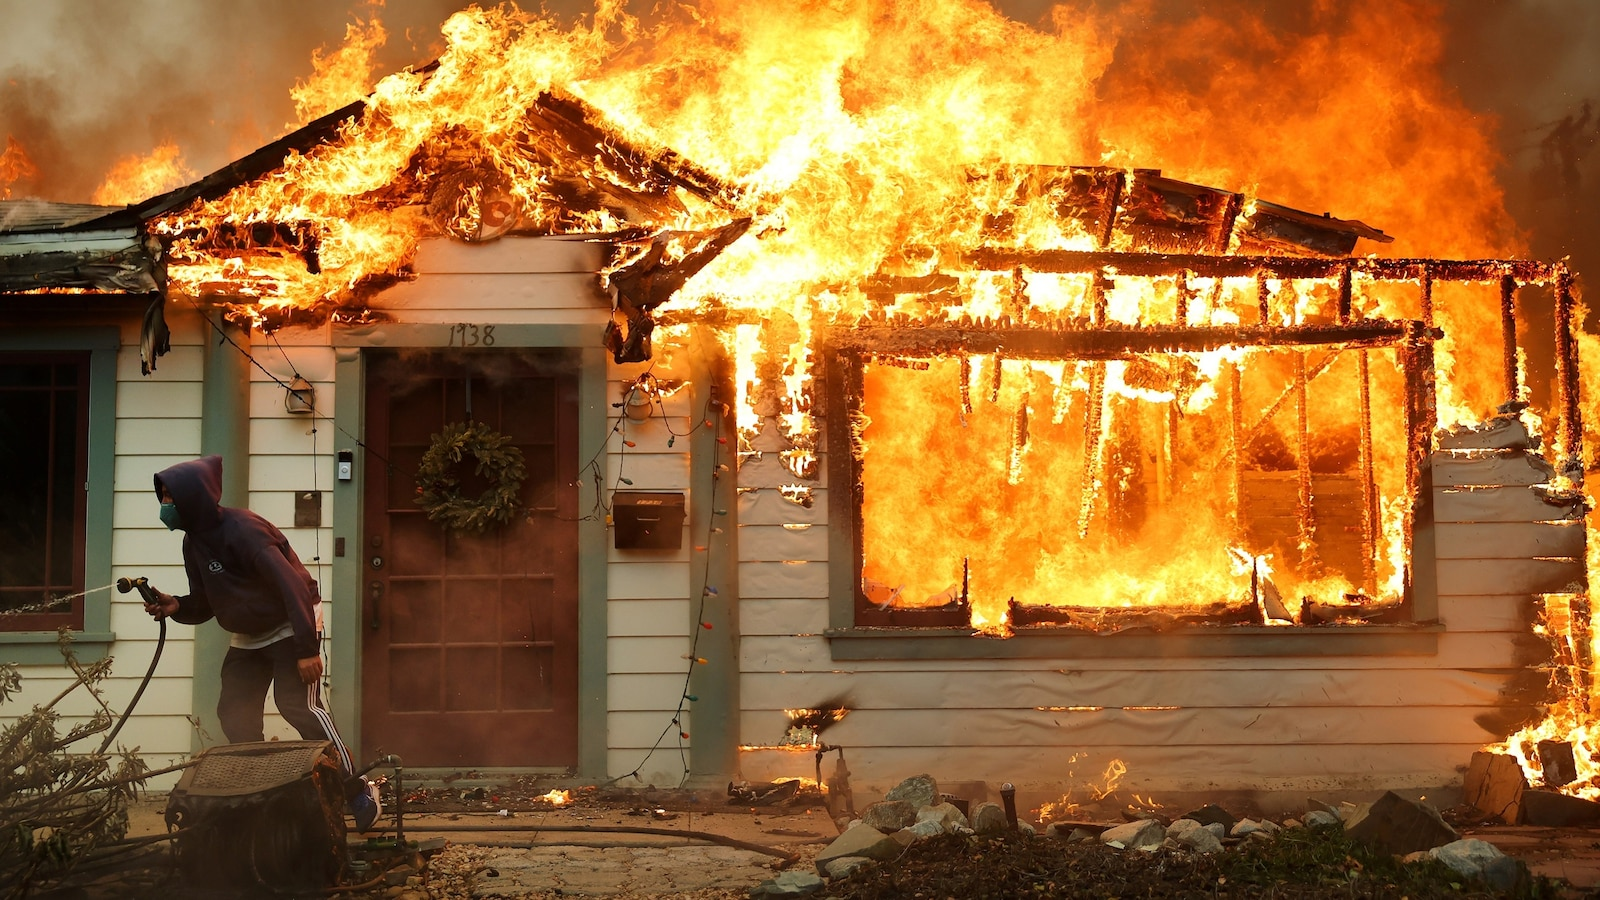

Processor type: Gemma4Processor
Image processor: Gemma4ImageProcessor
Processor keys: ['input_ids', 'attention_mask', 'mm_token_type_ids', 'pixel_values', 'image_position_ids']
Pixel values shape: (1, 2520, 768)
Pixel values dtype: torch.float32
Input ids shape: (1, 285)
Image token id: 258880
Image token count: 264
Prompt preview: <bos><|turn>user
<|image|>Briefly describe what is visible in the image.<turn|>
<|turn>model

--- Simple description ---
{'role': 'assistant', 'content': "This image depicts a scene of intense **fire and destruction**, likely involving a building.\n\nHere's a breakdown of what is visible:\n\n* **Fire:** The most dominant feature is a massive, raging fire engulfing a structure, producing bright orange and yellow flames.\n* **Building:** A wooden or clapboard building is clearly visible, heavily damaged by the fire. The roof is completely ablaze, and the walls show signs of intense heat and damage. A window is visible, framed by charred wood.\n* **Activity:** 

In [ ]:
# Update to an image available in the environment
test_image = '/content/fire_1.jpg'

simple_prompt = 'Briefly describe what is visible in the image.'
task_prompt = 'Describe the incident, assess risk level, and suggest response actions.'

verify_image(test_image)
inspect_multimodal_inputs(test_image, simple_prompt)
debug_prompt_preview(simple_prompt)

print('--- Simple description ---')
print(run_multimodal(test_image, simple_prompt))

print('--- Incident analysis ---')
print(run_multimodal(test_image, task_prompt))

In [ ]:
import nest_asyncio
from pyngrok import ngrok
import uvicorn
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from typing import List, Optional
import base64
import io
from PIL import Image

app = FastAPI()

app.add_middleware(
    CORSMiddleware,
    allow_origins=['*'],
    allow_credentials=False,
    allow_methods=['*'],
    allow_headers=['*'],
)

class InferRequest(BaseModel):
    request_id: Optional[str] = None
    prompt: str
    frames: List[str]

class Report(BaseModel):
    id: str
    location: str = '16.5062, 80.6480'
    risk_level: str = 'High'
    help_needed: str = 'Unknown'
    description: str = ''
    confidence: float = 0.5

class OrchestrateRequest(BaseModel):
    request_id: Optional[str] = None
    reports: List[Report]
    objective: str = 'Prioritize incidents and produce a response plan.'

@app.post('/infer')
def infer(req: InferRequest):
    if not req.frames:
        return {'error': 'No frames provided'}
    # Decode first frame
    frame_data = req.frames[0]
    if frame_data.startswith('data:image'):
        frame_data = frame_data.split(',')[1]
    image_bytes = base64.b64decode(frame_data)
    image = Image.open(io.BytesIO(image_bytes)).convert('RGB')

    # Temporarily save to disk as run_multimodal expects a path in the current notebook setup
    tmp_path = '/tmp/infer_frame.jpg'
    os.makedirs('/tmp', exist_ok=True)
    image.save(tmp_path)

    response_text = run_multimodal(tmp_path, req.prompt)

    # For /infer we just return the raw text, the frontend's parseChatContent handles it
    return {
        'request_id': req.request_id,
        'choices': [{'message': {'content': response_text}}]
    }

@app.post('/orchestrate')
def orchestrate(req: OrchestrateRequest):
    # Basecamp orchestration: aggregate reports and formulate a deployment plan
    reports_summary = '\n'.join([f'[{r.id}] Location: {r.location}, Risk: {r.risk_level}, Needs: {r.help_needed}, Desc: {r.description}' for r in req.reports])

    prompt = (
        'You are the Basecamp Rescue Coordinator. You have received the following incident reports:\n'
        f'{reports_summary}\n\n'
        f'Objective: {req.objective}\n'
        'Analyze the incidents, aggregate the data, map coordinates mentally, and prioritize them by risk level.\n'
        'Output ONLY a raw JSON object with these exact keys:\n'
        '{\n'
        '  "summary": "Single paragraph summary of the overall disaster situation.",\n'
        '  "prioritized_incidents": ["List of report IDs in order of priority"],\n'
        '  "deployment_recommendations": ["Action 1 (e.g. Route team A to location X)", "Action 2", "Action 3"]\n'
        '}\n'
    )

    # Text-only generation using the multimodal model
    messages = [{'role': 'user', 'content': [{'type': 'text', 'text': prompt}]}]
    chat_prompt = build_prompt(messages)
    inputs = processor(text=chat_prompt, return_tensors='pt', padding=True)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    input_len = inputs['input_ids'].shape[-1]

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=512,
            do_sample=True,
            temperature=0.2,
        )

    response_text = processor.decode(output_ids[0][input_len:], skip_special_tokens=True)

    # Extract JSON cleanly in case the model returns fenced markdown
    import re
    cleaned = re.sub(r'^```json\s*|```$', '', response_text.strip(), flags=re.IGNORECASE | re.MULTILINE)
    match = re.search(r'\{[\s\S]*\}', cleaned)
    if match:
        try:
            return json.loads(match.group(0))
        except:
            pass

    return {
        'request_id': req.request_id,
        'raw_response': response_text
    }

# Start ngrok and uvicorn
try:
    ngrok_token = userdata.get('NGROK_AUTHTOKEN')
    ngrok.set_auth_token(ngrok_token)
except Exception:
    print('NGROK_AUTHTOKEN not found in userdata. Please set it in Colab secrets.')

public_url = ngrok.connect(8000).public_url
print('='*50)
print(f'NGROK PUBLIC URL: {public_url}')
print('Set this URL as VITE_BASECAMP_API_URL and VITE_KAGGLE_API_URL in your frontend .env')
print('='*50)

import threading
threading.Thread(target=lambda: uvicorn.run(app, host='0.0.0.0', port=8000), daemon=True).start()
print('Server started in background thread.')


NGROK PUBLIC URL: https://unhurting-nonmediative-deegan.ngrok-free.dev
Set this URL as VITE_BASECAMP_API_URL and VITE_KAGGLE_API_URL in your frontend .env
Server started in background thread.
